In [10]:
# FashionMnist dataset에 이미지 보강 후 분류
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import matplotlib.pyplot as plt
import numpy as np
import os

np.random.seed(0)
tf.random.set_seed(0)

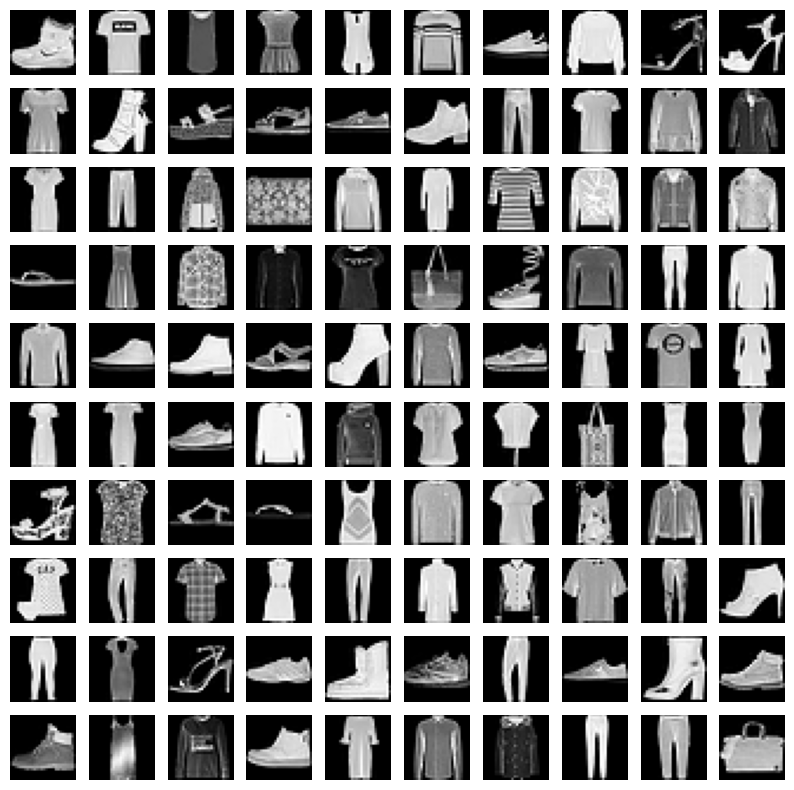

In [11]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

x_train = x_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
x_test = x_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0
# print(x_train[0])

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)
# print(y_train[:5])

# 시각화
plt.figure(figsize=(10, 10))
for i in range(100):
  plt.subplot(10, 10, i+1)
  plt.axis('off')
  plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
plt.show()

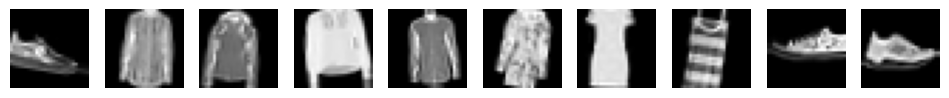

최종 학습 데이터 크기: (15000, 28, 28, 1)


In [12]:
# 데이터 양을 대폭 축소 (CPU 학습용)
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. 원본 데이터 중 10,000개만 샘플링
train_idx = np.random.randint(x_train.shape[0], size=10000)
x_train_small = x_train[train_idx]
y_train_small = y_train[train_idx]

# 2. 이미지 보강 양도 5,000개로 축소
train_datagen = ImageDataGenerator(
  rotation_range=10,
  zoom_range=0.1,
  width_shift_range=0.1,
  height_shift_range=0.1,
  horizontal_flip=True
)

augment_size = 5000
randidx = np.random.randint(x_train_small.shape[0], size=augment_size)
x_augment = x_train_small[randidx].copy()
y_augment = y_train_small[randidx].copy()

gen = train_datagen.flow(x_augment, y_augment, batch_size=augment_size, shuffle=False)
x_augmented, y_augmented = next(gen)

# 증강 이미지 일부 시각화
plt.figure(figsize=(12, 3))
for i in range(10):
  plt.subplot(1,10, i + 1)
  plt.axis('off')
  plt.imshow(x_augmented[i].reshape(28, 28), cmap='gray')
plt.show()

# 3. 최종 데이터 합치기 (총 15,000개)
x_train_final = np.concatenate([x_train_small, x_augmented], axis=0)
y_train_final = np.concatenate([y_train_small, y_augmented], axis=0)

print(f"최종 학습 데이터 크기: {x_train_final.shape}")

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input

# 가벼운 모델 구성
model = Sequential([
    Input(shape=(28, 28, 1)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# CPU 환경을 위해 Epoch 축소 및 EarlyStopping 강화
MODEL_DIR = './fmnist/'
if not os.path.exists(MODEL_DIR): os.mkdir(MODEL_DIR)
modelpath = './fmnist/cpu_model.keras'

checkpoint = ModelCheckpoint(filepath=modelpath, monitor='val_loss', verbose=1, save_best_only=True)
early_stopping = EarlyStopping(monitor='val_loss', patience=5)

# 학습 시작 (축소된 데이터 사용)
history = model.fit(x_train_final, y_train_final,
                    validation_data=(x_test, y_test),
                    epochs=15,
                    batch_size=64,
                    callbacks=[checkpoint, early_stopping])

Epoch 1/15
233/235 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5424 - loss: 1.2758
Epoch 1: val_loss improved from None to 0.51062, saving model to ./fmnist/cpu_model.keras

Epoch 1: finished saving model to ./fmnist/cpu_model.keras
235/235 ━━━━━━━━━━━━━━━━━━━━ 12s 43ms/step - accuracy: 0.6548 - loss: 0.9596 - val_accuracy: 0.8134 - val_loss: 0.5106
Epoch 2/15
233/235 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.7673 - loss: 0.6655
Epoch 2: val_loss improved from 0.51062 to 0.43527, saving model to ./fmnist/cpu_model.keras

Epoch 2: finished saving model to ./fmnist/cpu_model.keras
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - accuracy: 0.7776 - loss: 0.6260 - val_accuracy: 0.8439 - val_loss: 0.4353
Epoch 3/15
234/235 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8010 - loss: 0.5541
Epoch 3: val_loss improved from 0.43527 to 0.39766, saving model to ./fmnist/cpu_model.keras

Epoch 3: finished saving model to ./fmnist/cpu_model.keras
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - 

In [14]:
# test
loss, accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f'test acc : {accuracy:.4f}')

test acc : 0.8844


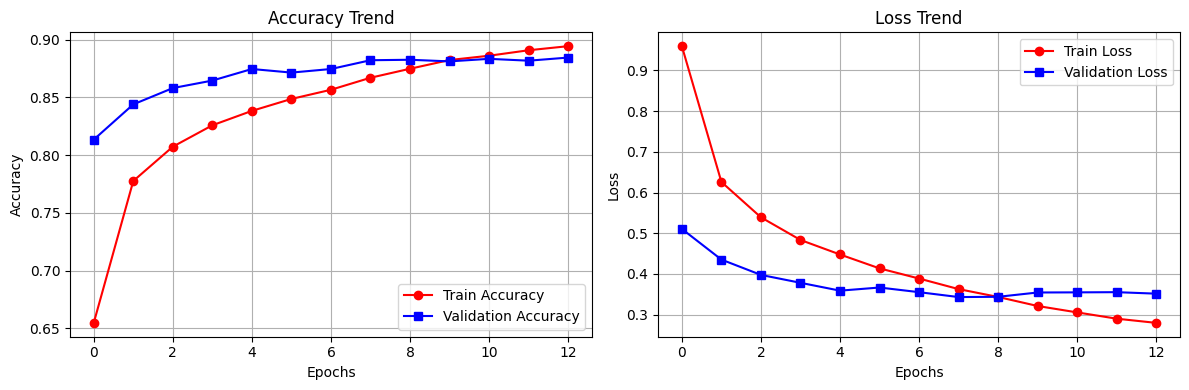

In [15]:
import matplotlib.pyplot as plt

# 시각화
plt.figure(figsize=(12, 4))

# 정확도 그래프
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], marker='o', color='r', label='Train Accuracy')
plt.plot(history.history['val_accuracy'],marker='s', color='b', label='Validation Accuracy')
plt.title('Accuracy Trend')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# 손실 그래프
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'],marker='o', color='r', label='Train Loss')
plt.plot(history.history['val_loss'],marker='s', color='b', label='Validation Loss')
plt.title('Loss Trend')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()